In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

# Charger
df = pd.read_csv('../data/processed/reclamations_clean.csv')
X = df['texte_clean']
y = df['categorie']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vectoriser
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✅ Données prêtes : {X_train_vec.shape[0]} train, {X_test_vec.shape[0]} test")

C:\Users\suki\AppData\Local\Temp\ipykernel_14112\1336900839.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Données prêtes : 886 train, 222 test


In [2]:
modeles = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Naive Bayes': MultinomialNB(),
}

resultats = []

for nom, modele in modeles.items():
    print(f"\n🔧 Entraînement : {nom}...")
    modele.fit(X_train_vec, y_train)
    y_pred = modele.predict(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    resultats.append({
        'Modèle': nom,
        'Accuracy': acc,
        'F1-Score': f1
    })
    print(f"   Accuracy : {acc*100:.2f}%  |  F1-Score : {f1*100:.2f}%")

# Tableau comparatif
df_resultats = pd.DataFrame(resultats).sort_values('F1-Score', ascending=False)
print("\n" + "=" * 60)
print("CLASSEMENT DES MODÈLES")
print("=" * 60)
print(df_resultats.to_string(index=False))


🔧 Entraînement : Logistic Regression...
   Accuracy : 78.83%  |  F1-Score : 79.12%

🔧 Entraînement : Linear SVM...
   Accuracy : 81.98%  |  F1-Score : 82.01%

🔧 Entraînement : Random Forest...


C:\Users\suki\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


   Accuracy : 83.33%  |  F1-Score : 83.35%

🔧 Entraînement : Naive Bayes...
   Accuracy : 69.37%  |  F1-Score : 67.39%

CLASSEMENT DES MODÈLES
             Modèle  Accuracy  F1-Score
      Random Forest  0.833333  0.833488
         Linear SVM  0.819820  0.820078
Logistic Regression  0.788288  0.791208
        Naive Bayes  0.693694  0.673880


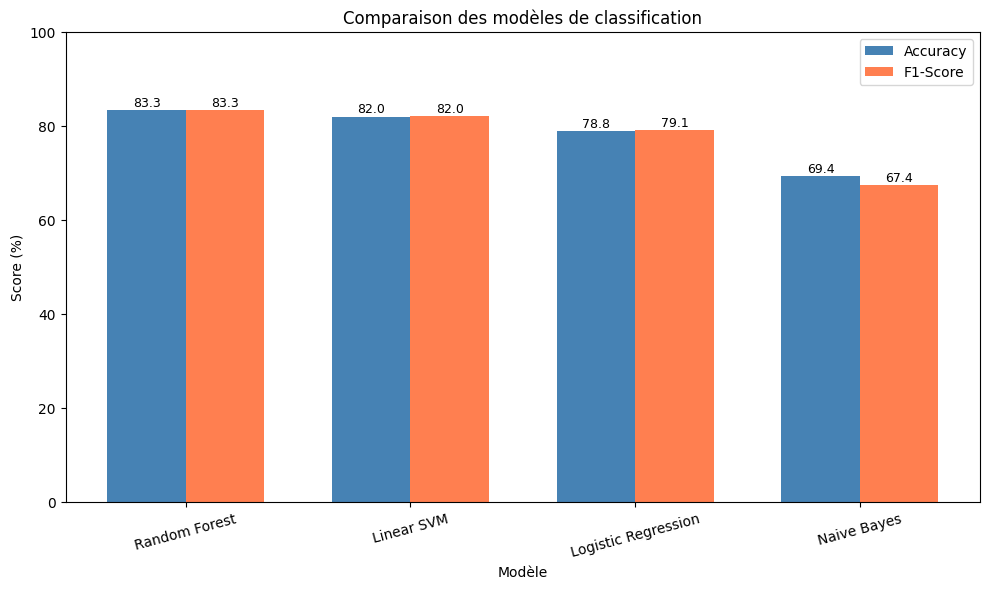

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(df_resultats))
width = 0.35

bars1 = ax.bar(x_pos - width/2, df_resultats['Accuracy']*100, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x_pos + width/2, df_resultats['F1-Score']*100, width, label='F1-Score', color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Score (%)')
ax.set_title('Comparaison des modèles de classification')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_resultats['Modèle'], rotation=15)
ax.legend()
ax.set_ylim(0, 100)

# Afficher les valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/comparaison_modeles.png', dpi=100, bbox_inches='tight')
plt.show()

In [4]:
# La validation croisée est plus fiable que la simple division train/test
# Elle entraîne le modèle 5 fois sur différentes parties des données

meilleur_modele_nom = df_resultats.iloc[0]['Modèle']
meilleur_modele = modeles[meilleur_modele_nom]

print(f"Validation croisée du meilleur modèle : {meilleur_modele_nom}")
print("(Cela prend ~30 secondes)")

scores = cross_val_score(meilleur_modele, X_train_vec, y_train, 
                          cv=5, scoring='f1_weighted', n_jobs=-1)

print(f"\nScores des 5 folds : {[f'{s:.3f}' for s in scores]}")
print(f"Moyenne : {scores.mean()*100:.2f}%")
print(f"Écart-type : {scores.std()*100:.2f}%")

Validation croisée du meilleur modèle : Random Forest
(Cela prend ~30 secondes)

Scores des 5 folds : ['0.824', '0.841', '0.765', '0.844', '0.783']
Moyenne : 81.14%
Écart-type : 3.17%
